In [35]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats

# Toggle x-axis: True = distinct_words, False = total_frequency
USE_DISTINCT_WORDS = False
# Toggle y-axis metric: True = _types (distinct words), False = _tokens (total frequency)
Y_USE_DISTINCT_WORDS = True

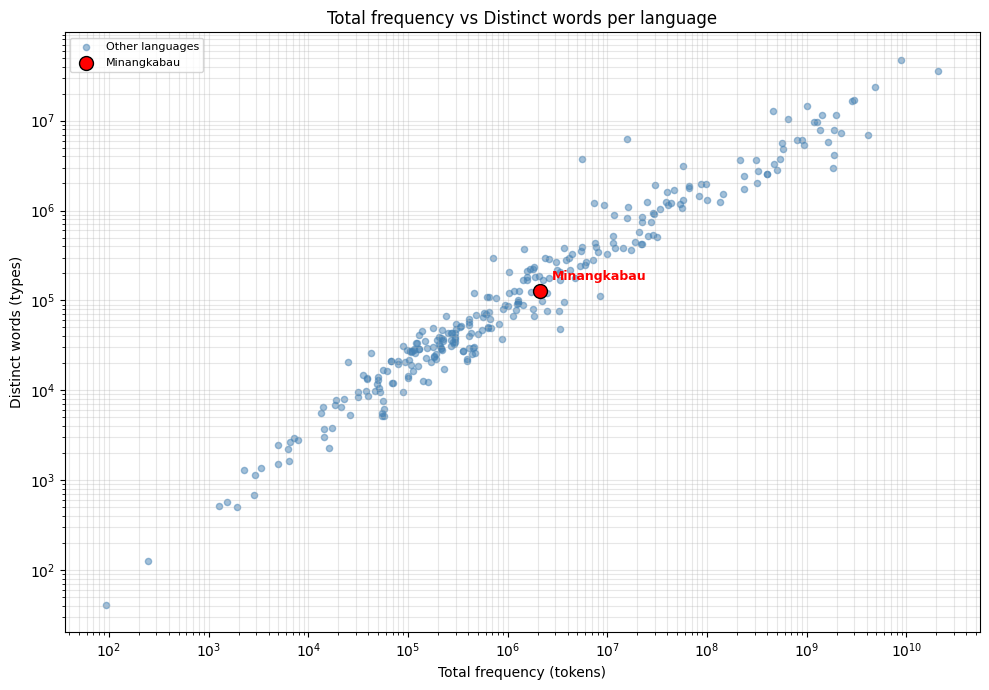

In [36]:

# ── Total frequency vs Distinct words per language ──────────

stats = pd.read_csv("../../results/0_data_processing/statistics.csv")
shortcuts = pd.read_csv("../../src/0_data_processing/corpora/leipzig/lepzig_shortcuts.csv")
stats_m = stats.merge(shortcuts, left_on="file", right_on="code", how="left")
stats_m["name"] = stats_m["language"].fillna(stats_m["file"])

HIGHLIGHT = "Minangkabau"

fig, ax = plt.subplots(figsize=(10, 7))

mask_hl = stats_m["name"] == HIGHLIGHT
mask_rest = ~mask_hl

ax.scatter(stats_m.loc[mask_rest, "total_frequency"],
           stats_m.loc[mask_rest, "distinct_words"],
           alpha=0.5, s=20, color="steelblue", label="Other languages")

ax.scatter(stats_m.loc[mask_hl, "total_frequency"],
           stats_m.loc[mask_hl, "distinct_words"],
           s=100, color="red", zorder=10, edgecolors="black", label=HIGHLIGHT)

for _, row in stats_m[mask_hl].iterrows():
    ax.annotate(row["name"], (row["total_frequency"], row["distinct_words"]),
                fontsize=9, fontweight="bold", color="red",
                xytext=(8, 8), textcoords="offset points")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Total frequency (tokens)")
ax.set_ylabel("Distinct words (types)")
ax.set_title("Total frequency vs Distinct words per language")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


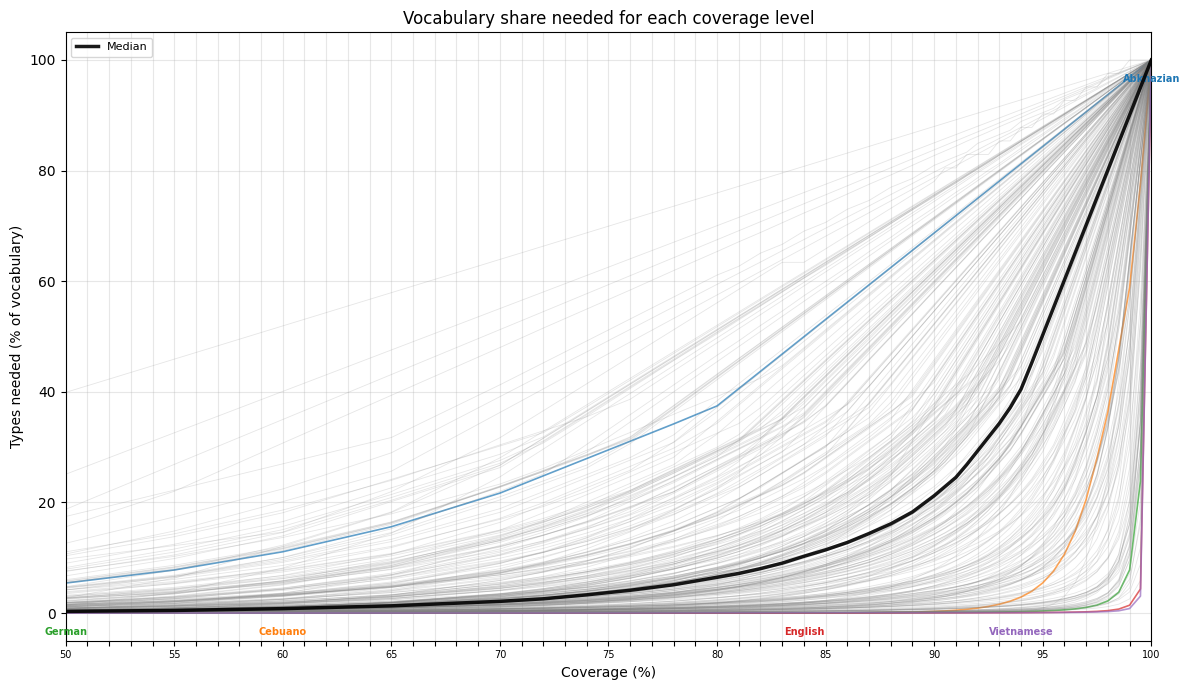

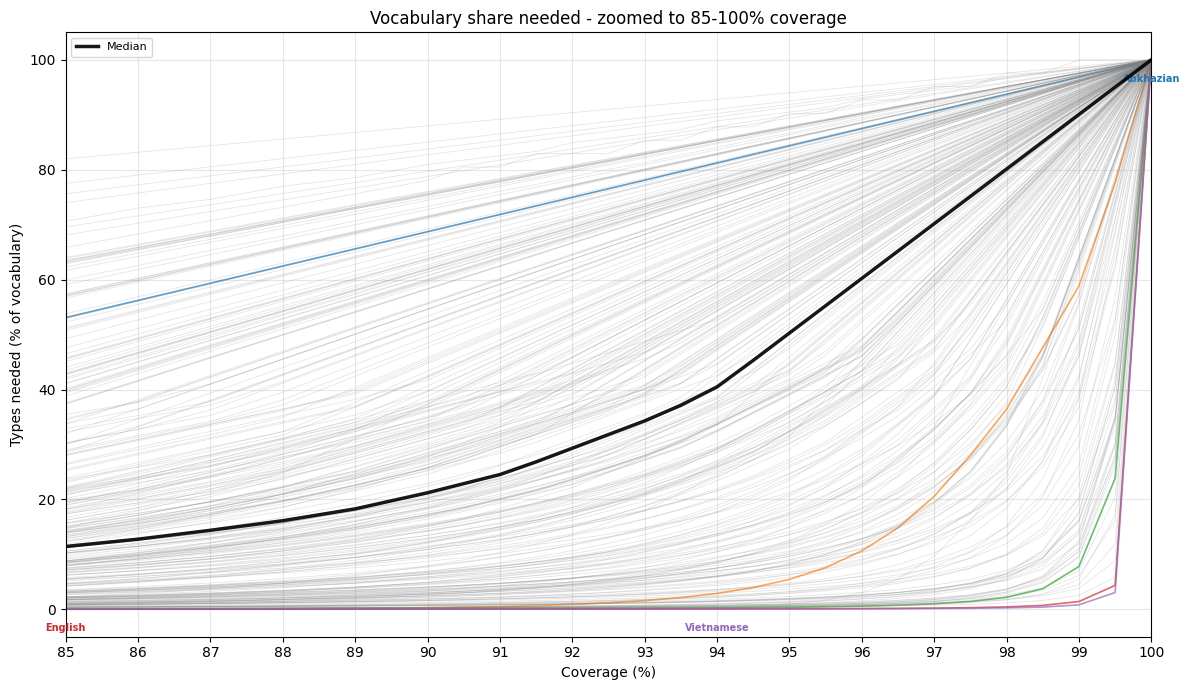

In [37]:

# ── Coverage curve: % of vocabulary needed for each coverage level ──

stats = pd.read_csv("../../results/0_data_processing/statistics.csv")

# Extract coverage levels from column names
cov_cols = [c for c in stats.columns if c.startswith("cov_") and c.endswith("_types")]
cov_levels = []
for c in cov_cols:
    # "cov_90_5_types" -> 90.5,  "cov_95_types" -> 95.0
    inner = c[len("cov_"):-len("_types")]
    parts = inner.split("_")
    if len(parts) == 2:
        cov_levels.append(float(f"{parts[0]}.{parts[1]}"))
    else:
        cov_levels.append(float(parts[0]))

cov_levels = np.array(cov_levels)

# Build matrix: rows=languages, cols=coverage levels (% of vocab)
shortcuts = pd.read_csv("../../src/0_data_processing/corpora/leipzig/lepzig_shortcuts.csv")
stats_m = stats.merge(shortcuts, left_on="file", right_on="code", how="left")
names = stats_m["language"].fillna(stats_m["file"]).values

pct_matrix = np.zeros((len(stats), len(cov_cols)))
valid = stats["distinct_words"] > 0
for i, (_, row) in enumerate(stats.iterrows()):
    if valid.iloc[i]:
        pct_matrix[i] = [row[c] / row["distinct_words"] * 100 for c in cov_cols]
    else:
        pct_matrix[i] = np.nan

# Find languages that are ever the lowest line
min_idx = np.nanargmin(pct_matrix, axis=0)
bottom_langs = set(min_idx)

# Median curve across all valid languages
median_pct = np.nanmedian(pct_matrix[valid.values], axis=0)

# ── Full range plot (50-100%) ──
fig, ax = plt.subplots(figsize=(12, 7))

lines = {}
for i in range(len(stats)):
    if not valid.iloc[i]:
        continue
    if i in bottom_langs:
        line, = ax.plot(cov_levels, pct_matrix[i], alpha=0.7, linewidth=1.2)
        lines[i] = line
    else:
        ax.plot(cov_levels, pct_matrix[i], alpha=0.2, linewidth=0.6, color="gray")

# Label bottom languages at the point where they first become the lowest
labeled = set()
for j, idx in enumerate(min_idx):
    if idx not in labeled:
        labeled.add(idx)
        ax.annotate(
            names[idx], (cov_levels[j], pct_matrix[idx, j]),
            fontsize=7, fontweight="bold", color=lines[idx].get_color(),
            xytext=(0, -10), textcoords="offset points",
            ha="center", va="top",
        )

ax.plot(cov_levels, median_pct, color="black", linewidth=2.5, alpha=0.9,
        linestyle="-", label="Median", zorder=10)

#ax.set_yscale("log")
ax.set_xlabel("Coverage (%)")
ax.set_ylabel("Types needed (% of vocabulary)")
ax.set_title("Vocabulary share needed for each coverage level")
ax.set_xticks(np.arange(50, 101, 1))
ax.set_xticklabels([str(int(x)) if x % 5 == 0 else "" for x in np.arange(50, 101, 1)],
                    fontsize=7)
ax.set_xlim(50, 100)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# ── Zoomed view: 85-100% coverage ──
fig2, ax2 = plt.subplots(figsize=(12, 7))

mask85 = cov_levels >= 85
levels85 = cov_levels[mask85]

for i in range(len(stats)):
    if not valid.iloc[i]:
        continue
    if i in bottom_langs:
        ax2.plot(levels85, pct_matrix[i, mask85], alpha=0.7, linewidth=1.2,
                 color=lines[i].get_color())
    else:
        ax2.plot(levels85, pct_matrix[i, mask85], alpha=0.2, linewidth=0.6, color="gray")

# Re-label bottom languages in the zoomed range
min_idx_85 = np.nanargmin(pct_matrix[:, mask85], axis=0)
labeled85 = set()
for j, idx in enumerate(min_idx_85):
    if idx not in labeled85 and idx in lines:
        labeled85.add(idx)
        ax2.annotate(
            names[idx], (levels85[j], pct_matrix[idx, np.where(mask85)[0][j]]),
            fontsize=7, fontweight="bold", color=lines[idx].get_color(),
            xytext=(0, -10), textcoords="offset points",
            ha="center", va="top",
        )

ax2.plot(levels85, median_pct[mask85], color="black", linewidth=2.5, alpha=0.9,
         linestyle="-", label="Median", zorder=10)

#ax2.set_yscale("log")
ax2.set_xlabel("Coverage (%)")
ax2.set_ylabel("Types needed (% of vocabulary)")
ax2.set_title("Vocabulary share needed - zoomed to 85-100% coverage")
ax2.set_xticks(np.arange(85, 101, 1))
ax2.set_xlim(85, 100)
ax2.legend(fontsize=8, loc="upper left")
ax2.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


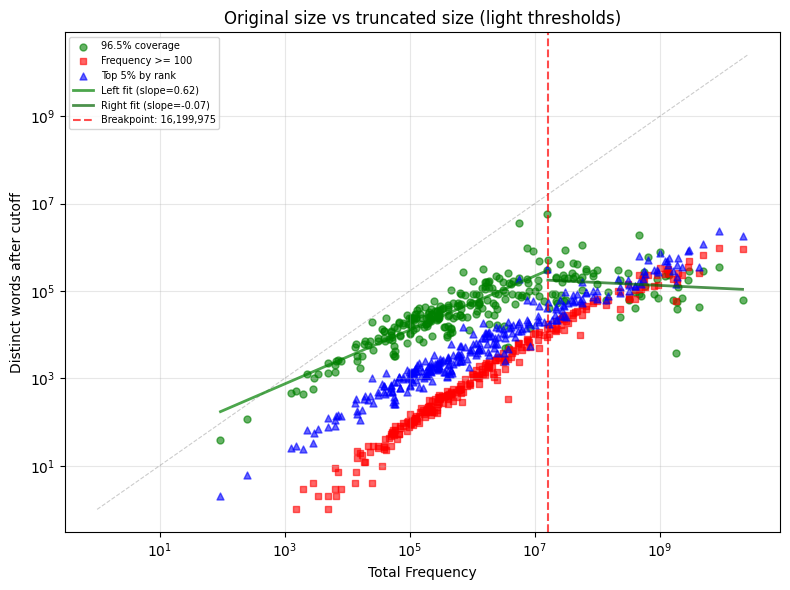

Pearson correlations (log-log) between total_frequency and truncated size:
  96.5% coverage      : r = 0.7584
  Frequency >= 100    : r = 0.9855 (skipped 5 with 0)
  Top 5% by rank      : r = 0.9769


In [38]:

# ── Cutoff comparison: original size vs truncated size ──────

stats = pd.read_csv("../../results/0_data_processing/statistics.csv")

# Switch between "light" and "dark" thresholds
threshold = "light"  # "light" = (96.5% cov, freq>=100, rank 5%)  |  "strict" = (99% cov, freq>=10, rank 30%)

y_suffix = "_types" if Y_USE_DISTINCT_WORDS else "_tokens"
if threshold == "light":
    cov_col = f"cov_96_5{y_suffix}"
    metrics = [
        (f"cov_96_5{y_suffix}",  "96.5% coverage", "green", "o"),
        (f"freq100{y_suffix}",   "Frequency >= 100", "red", "s"),
        (f"rank5pct{y_suffix}",  "Top 5% by rank", "blue", "^"),
    ]
else:
    cov_col = f"cov_99{y_suffix}"
    metrics = [
        (f"cov_99{y_suffix}",    "99% coverage", "green", "o"),
        (f"freq10{y_suffix}",    "Frequency >= 10", "red", "s"),
        (f"rank30pct{y_suffix}", "Top 30% by rank", "blue", "^"),
    ]

# ── Piecewise regression breakpoint on coverage (green) dots ─
x_col = "distinct_words" if USE_DISTINCT_WORDS else "total_frequency"
mask_bp = (stats[x_col] > 0) & (stats[cov_col] > 0)
log_x_bp = np.log10(stats.loc[mask_bp, x_col].values)
log_y_bp = np.log10(stats.loc[mask_bp, cov_col].values)
order = np.argsort(log_x_bp)
log_x_bp, log_y_bp = log_x_bp[order], log_y_bp[order]
n_bp = len(log_x_bp)
min_seg = 15
cands = log_x_bp[min_seg : n_bp - min_seg]
rss_vals = []
for b in cands:
    lm, rm = log_x_bp <= b, log_x_bp > b
    sl, ic, *_ = sp_stats.linregress(log_x_bp[lm], log_y_bp[lm])
    rss_l = np.sum((log_y_bp[lm] - (ic + sl * log_x_bp[lm])) ** 2)
    sl, ic, *_ = sp_stats.linregress(log_x_bp[rm], log_y_bp[rm])
    rss_r = np.sum((log_y_bp[rm] - (ic + sl * log_x_bp[rm])) ** 2)
    rss_vals.append(rss_l + rss_r)
bp_log = cands[np.argmin(rss_vals)]
bp_x = 10 ** bp_log

# Fit lines for left/right segments
lm, rm = log_x_bp <= bp_log, log_x_bp > bp_log
sl_l, ic_l, *_ = sp_stats.linregress(log_x_bp[lm], log_y_bp[lm])
sl_r, ic_r, *_ = sp_stats.linregress(log_x_bp[rm], log_y_bp[rm])

fig, ax = plt.subplots(figsize=(8, 6))

for col, label, color, marker in metrics:
    ax.scatter(stats[x_col], stats[col], alpha=0.6,
               color=color, marker=marker, label=label, s=25)

# Diagonal reference line (y = x)
lims = [1, max(stats[x_col].max(), stats[metrics[0][0]].max()) * 1.2]
ax.plot(lims, lims, "k--", alpha=0.2, linewidth=0.8)

# Piecewise regression lines (in original log-log scale)
xl = np.logspace(log_x_bp[lm].min(), bp_log, 50)
xr = np.logspace(bp_log, log_x_bp[rm].max(), 50)
ax.plot(xl, 10 ** (ic_l + sl_l * np.log10(xl)), color="green", linewidth=2, alpha=0.7,
        label=f"Left fit (slope={sl_l:.2f})")
ax.plot(xr, 10 ** (ic_r + sl_r * np.log10(xr)), color="darkgreen", linewidth=2, alpha=0.7,
        label=f"Right fit (slope={sl_r:.2f})")

# Breakpoint vertical line
ax.axvline(bp_x, color="red", linestyle="--", linewidth=1.5, alpha=0.7,
           label=f"Breakpoint: {bp_x:,.0f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(x_col.replace("_", " ").title())
y_label = "Distinct words after cutoff" if Y_USE_DISTINCT_WORDS else "Tokens after cutoff"
ax.set_ylabel(y_label)
ax.set_title(f"Original size vs truncated size ({threshold} thresholds)")
ax.legend(fontsize=7)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Correlations (Pearson on log-transformed values to match the log-log plot)
print(f"Pearson correlations (log-log) between {x_col} and truncated size:")
for col, label, _, _ in metrics:
    mask = stats[col] > 0
    r = np.corrcoef(np.log(stats.loc[mask, x_col]), np.log(stats.loc[mask, col]))[0, 1]
    skipped = (~mask).sum()
    extra = f" (skipped {skipped} with 0)" if skipped else ""
    print(f"  {label:20s}: r = {r:.4f}{extra}")


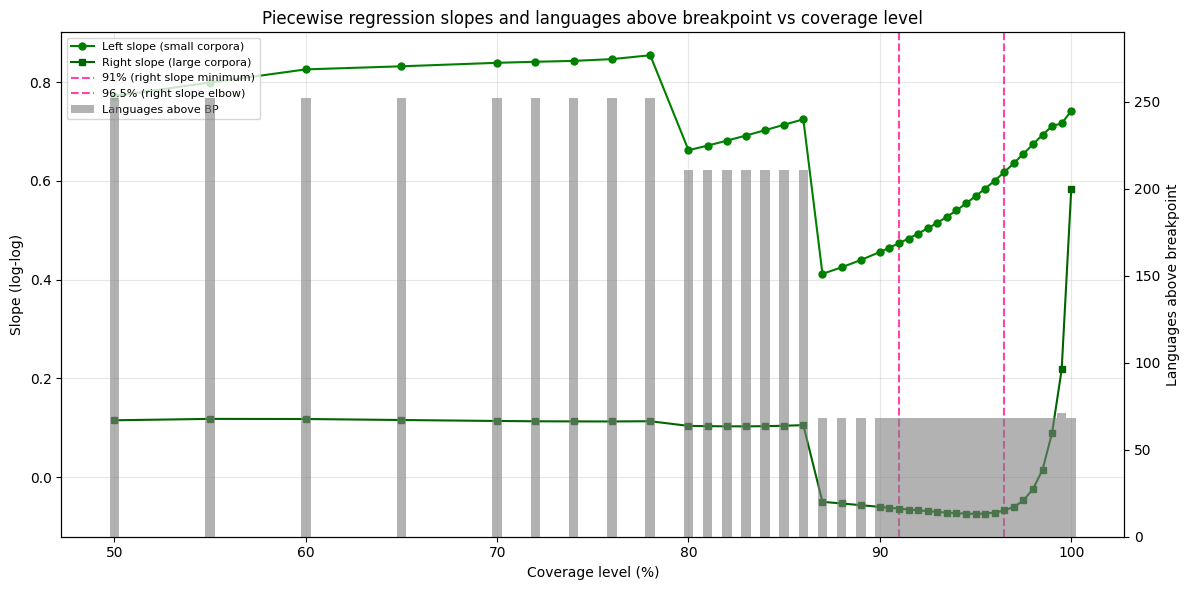

  Coverage     Breakpoint  n_right   Slope L   Slope R   Δ Slope  Sig?
---------------------------------------------------------------------------
     50.0%        42,361      252    0.7721    0.1152    0.6569   Yes
     55.0%        42,361      252    0.7992    0.1180    0.6812   Yes
     60.0%        42,361      252    0.8258    0.1178    0.7081   Yes
     65.0%        42,361      252    0.8321    0.1157    0.7163   Yes
     70.0%        42,361      252    0.8392    0.1138    0.7254   Yes
     72.0%        42,361      252    0.8413    0.1132    0.7281   Yes
     74.0%        42,361      252    0.8431    0.1129    0.7301   Yes
     76.0%        42,361      252    0.8466    0.1128    0.7338   Yes
     78.0%        42,361      252    0.8544    0.1133    0.7412   Yes
     80.0%       139,280      211    0.6622    0.1038    0.5583   Yes
     81.0%       139,280      211    0.6715    0.1033    0.5681   Yes
     82.0%       139,280      211    0.6815    0.1029    0.5785   Yes
     83.0%   

In [39]:

# ── Breakpoint vs coverage level ────────────────────────────
# For each coverage level, find the piecewise-regression breakpoint
# (same method as the 95% analysis above) and plot how it changes.

stats = pd.read_csv("../../results/0_data_processing/statistics.csv")

# Extract all coverage columns and their numeric levels
y_sfx = "_types" if Y_USE_DISTINCT_WORDS else "_tokens"
cov_cols = [c for c in stats.columns if c.startswith("cov_") and c.endswith(y_sfx)]
cov_levels = []
for c in cov_cols:
    inner = c[len("cov_"):-len(y_sfx)]
    parts = inner.split("_")
    if len(parts) == 2:
        cov_levels.append(float(f"{parts[0]}.{parts[1]}"))
    else:
        cov_levels.append(float(parts[0]))

x_col = "distinct_words" if USE_DISTINCT_WORDS else "total_frequency"
min_segment = 15

breakpoints = []
slopes_left = []
slopes_right = []
f_stats = []
p_values = []
n_valid_list = []
n_left_list = []
n_right_list = []

for cov_col, cov_level in zip(cov_cols, cov_levels):
    mask = (stats[x_col] > 0) & (stats[cov_col] > 0)
    n_valid = mask.sum()
    if n_valid < 2 * min_segment + 1:
        breakpoints.append(np.nan); slopes_left.append(np.nan); slopes_right.append(np.nan)
        f_stats.append(np.nan); p_values.append(np.nan)
        n_valid_list.append(n_valid); n_left_list.append(np.nan); n_right_list.append(np.nan)
        continue

    log_x = np.log10(stats.loc[mask, x_col].values)
    log_y = np.log10(stats.loc[mask, cov_col].values)
    order = np.argsort(log_x)
    log_x, log_y = log_x[order], log_y[order]
    n = len(log_x)

    candidates = log_x[min_segment : n - min_segment]
    if len(candidates) == 0:
        breakpoints.append(np.nan); slopes_left.append(np.nan); slopes_right.append(np.nan)
        f_stats.append(np.nan); p_values.append(np.nan)
        n_valid_list.append(n_valid); n_left_list.append(np.nan); n_right_list.append(np.nan)
        continue

    rss_values = []
    for b in candidates:
        left = log_x <= b
        right = ~left
        sl_l, ic_l, _, _, _ = sp_stats.linregress(log_x[left], log_y[left])
        rss_l = np.sum((log_y[left] - (ic_l + sl_l * log_x[left])) ** 2)
        sl_r, ic_r, _, _, _ = sp_stats.linregress(log_x[right], log_y[right])
        rss_r = np.sum((log_y[right] - (ic_r + sl_r * log_x[right])) ** 2)
        rss_values.append(rss_l + rss_r)

    best_idx = np.argmin(rss_values)
    bp_log = candidates[best_idx]
    best_rss_pw = rss_values[best_idx]

    left_m = log_x <= bp_log
    right_m = ~left_m
    sl_l, ic_l, _, _, _ = sp_stats.linregress(log_x[left_m], log_y[left_m])
    sl_r, ic_r, _, _, _ = sp_stats.linregress(log_x[right_m], log_y[right_m])

    sl_full, ic_full, _, _, _ = sp_stats.linregress(log_x, log_y)
    rss_full = np.sum((log_y - (ic_full + sl_full * log_x)) ** 2)
    k = 2
    F_stat = ((rss_full - best_rss_pw) / k) / (best_rss_pw / (n - 2 * k))
    p_val = 1 - sp_stats.f.cdf(F_stat, k, n - 2 * k)

    breakpoints.append(10 ** bp_log); slopes_left.append(sl_l); slopes_right.append(sl_r)
    f_stats.append(F_stat); p_values.append(p_val)
    n_valid_list.append(n_valid); n_left_list.append(int(left_m.sum())); n_right_list.append(int(right_m.sum()))

cov_levels = np.array(cov_levels)
breakpoints = np.array(breakpoints)
slopes_left = np.array(slopes_left)
slopes_right = np.array(slopes_right)
p_values = np.array(p_values)
n_right_arr = np.array(n_right_list, dtype=float)

# ── Combined plot: slopes + language count on right axis ────
fig, ax = plt.subplots(figsize=(12, 6))

# Bar graph for number of languages above breakpoint (right y-axis)
ax2 = ax.twinx()
ax2.bar(cov_levels, n_right_arr, width=0.5, color="gray", alpha=0.6, label="Languages above BP", zorder=1)
ax2.set_ylabel("Languages above breakpoint")
ax2.set_ylim(0, 290)

# Slope lines (left y-axis, drawn on top)
ax.plot(cov_levels, slopes_left, "o-", color="green", markersize=5, linewidth=1.5,
        label="Left slope (small corpora)", zorder=5)
ax.plot(cov_levels, slopes_right, "s-", color="darkgreen", markersize=5, linewidth=1.5,
        label="Right slope (large corpora)", zorder=5)
ax.axvline(91, color="deeppink", linestyle="--", linewidth=1.5, alpha=0.8,
           label="91% (right slope minimum)", zorder=4)
ax.axvline(96.5, color="deeppink", linestyle="--", linewidth=1.5, alpha=0.8,
           label="96.5% (right slope elbow)", zorder=4)

ax.set_xlabel("Coverage level (%)")
ax.set_ylabel("Slope (log-log)")
ax.set_title("Piecewise regression slopes and languages above breakpoint vs coverage level")
ax.grid(True, alpha=0.3)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# ── Summary table ───────────────────────────────────────────
print(f"{'Coverage':>10} {'Breakpoint':>14} {'n_right':>8} {'Slope L':>9} {'Slope R':>9} {'Δ Slope':>9} {'Sig?':>5}")
print("-" * 75)
for i in range(len(cov_levels)):
    sig = "Yes" if p_values[i] < 0.05 else "No"
    nr = f"{n_right_arr[i]:.0f}" if not np.isnan(n_right_arr[i]) else "N/A"
    print(f"{cov_levels[i]:>9.1f}% {breakpoints[i]:>13,.0f} {nr:>8} {slopes_left[i]:>9.4f} {slopes_right[i]:>9.4f} "
          f"{slopes_left[i]-slopes_right[i]:>9.4f} {sig:>5}")


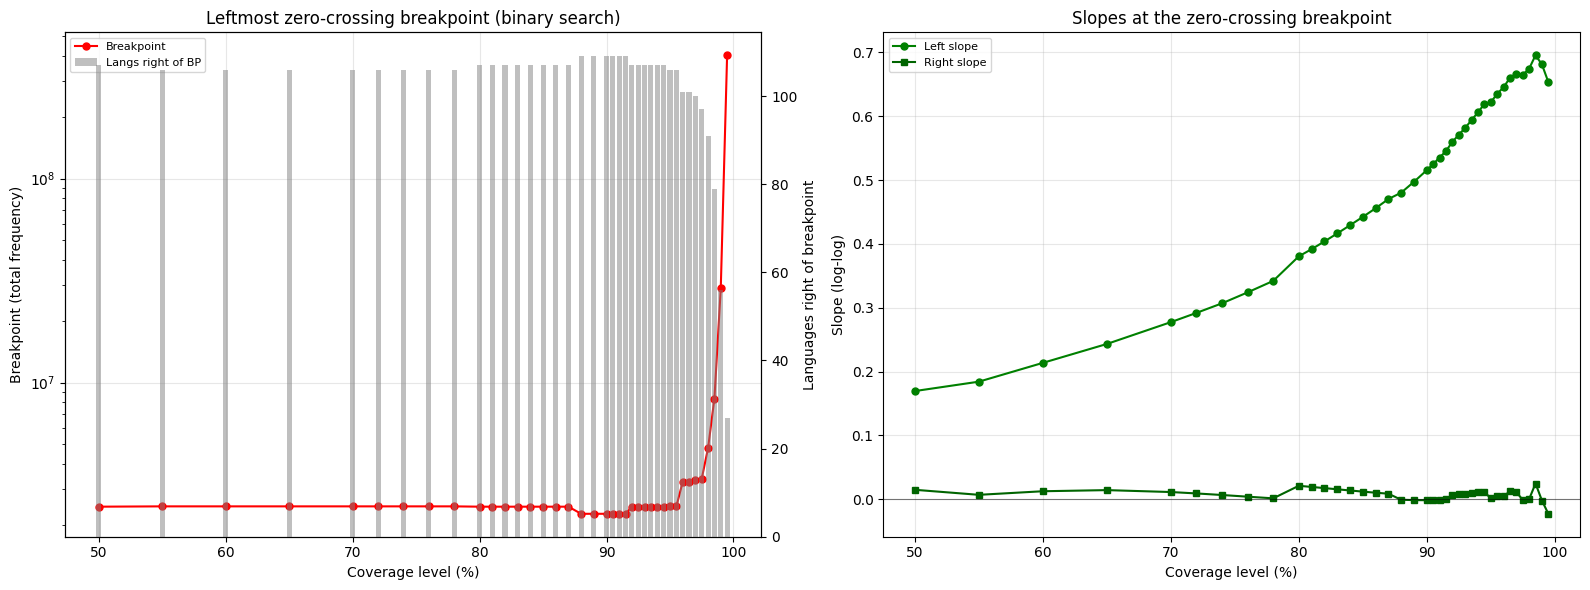

Best coverage (most languages right of zero-slope BP):
  Coverage:      88.0%
  Breakpoint:    2,272,873
  Right slope:   -0.000688
  Left slope:    0.4803
  Langs right:   109

All coverages with a zero-crossing breakpoint:
    Coverage      Breakpoint   Right slope   Left slope   n_right
       50.0%       2,462,919      0.014923       0.1696       107
       55.0%       2,471,748      0.007062       0.1843       106
       60.0%       2,471,748      0.012673       0.2138       106
       65.0%       2,471,748      0.014423       0.2433       106
       70.0%       2,471,748      0.011432       0.2775       106
       72.0%       2,471,748      0.009222       0.2920       106
       74.0%       2,471,748      0.006785       0.3070       106
       76.0%       2,471,748      0.004143       0.3242       106
       78.0%       2,471,748      0.001564       0.3421       106
       80.0%       2,462,919      0.021198       0.3806       107
       81.0%       2,462,919      0.019420       

In [40]:

# ── For each coverage level, find the leftmost split where right slope crosses zero ──
# Sweep breakpoints left-to-right, detect sign change, then binary search for exact zero.

stats_sw = pd.read_csv("../../results/0_data_processing/statistics.csv")
x_col_sw = "distinct_words" if USE_DISTINCT_WORDS else "total_frequency"
y_sfx_sw = "_types" if Y_USE_DISTINCT_WORDS else "_tokens"
cov_cols_sw = [c for c in stats_sw.columns if c.startswith("cov_") and c.endswith(y_sfx_sw)]
cov_levels_sw = []
for c in cov_cols_sw:
    inner = c[len("cov_"):-len(y_sfx_sw)]
    parts = inner.split("_")
    if len(parts) == 2:
        cov_levels_sw.append(float(f"{parts[0]}.{parts[1]}"))
    else:
        cov_levels_sw.append(float(parts[0]))

min_seg_sw = 15

def right_slope_at(log_x, log_y, bp_log):
    """Compute right-side slope for a given breakpoint in log space."""
    right = log_x > bp_log
    if right.sum() < 5:
        return np.nan
    sl, _, _, _, _ = sp_stats.linregress(log_x[right], log_y[right])
    return sl

def find_zero_crossing_bp(log_x, log_y, min_seg):
    """Sweep left-to-right, find first sign change in right slope, binary search for zero."""
    n = len(log_x)
    candidates = log_x[min_seg : n - min_seg]
    if len(candidates) < 2:
        return None

    # Compute right slopes at each candidate
    prev_slope = right_slope_at(log_x, log_y, candidates[0])
    for i in range(1, len(candidates)):
        curr_slope = right_slope_at(log_x, log_y, candidates[i])
        if np.isnan(prev_slope) or np.isnan(curr_slope):
            prev_slope = curr_slope
            continue
        # Sign change detected
        if prev_slope * curr_slope < 0:
            # Binary search between candidates[i-1] and candidates[i]
            lo, hi = candidates[i - 1], candidates[i]
            for _ in range(50):  # plenty of iterations for convergence
                mid = (lo + hi) / 2
                mid_slope = right_slope_at(log_x, log_y, mid)
                if np.isnan(mid_slope):
                    break
                if abs(mid_slope) < 1e-6:
                    break
                if mid_slope * prev_slope > 0:
                    lo = mid
                else:
                    hi = mid
            bp_final = (lo + hi) / 2
            final_slope = right_slope_at(log_x, log_y, bp_final)
            left_mask = log_x <= bp_final
            right_mask = log_x > bp_final
            sl_l, _, _, _, _ = sp_stats.linregress(log_x[left_mask], log_y[left_mask])
            return {
                "bp_log": bp_final,
                "bp_val": 10 ** bp_final,
                "right_slope": final_slope,
                "left_slope": sl_l,
                "n_right": int(right_mask.sum()),
                "n_left": int(left_mask.sum()),
            }
        prev_slope = curr_slope
    return None

results = []

for cov_col_sw, cov_level_sw in zip(cov_cols_sw, cov_levels_sw):
    mask_sw = (stats_sw[x_col_sw] > 0) & (stats_sw[cov_col_sw] > 0)
    if mask_sw.sum() < 2 * min_seg_sw + 1:
        results.append((cov_level_sw, np.nan, np.nan, np.nan, np.nan))
        continue

    log_x_sw = np.log10(stats_sw.loc[mask_sw, x_col_sw].values)
    log_y_sw = np.log10(stats_sw.loc[mask_sw, cov_col_sw].values)
    order_sw = np.argsort(log_x_sw)
    log_x_sw, log_y_sw = log_x_sw[order_sw], log_y_sw[order_sw]

    res = find_zero_crossing_bp(log_x_sw, log_y_sw, min_seg_sw)
    if res is not None:
        results.append((cov_level_sw, res["bp_val"], res["right_slope"], res["n_right"], res["left_slope"]))
    else:
        results.append((cov_level_sw, np.nan, np.nan, np.nan, np.nan))

res_df = pd.DataFrame(results, columns=["coverage", "breakpoint", "right_slope", "n_right", "left_slope"])
res_valid = res_df.dropna()

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: breakpoint position and n_right vs coverage
ax1b = ax1.twinx()
ax1.plot(res_valid["coverage"], res_valid["breakpoint"], "o-", color="red", markersize=5, label="Breakpoint")
ax1b.bar(res_valid["coverage"], res_valid["n_right"], width=0.4, color="gray", alpha=0.5, label="Langs right of BP")
ax1.set_xlabel("Coverage level (%)")
ax1.set_ylabel("Breakpoint (total frequency)")
ax1.set_yscale("log")
ax1b.set_ylabel("Languages right of breakpoint")
ax1.set_title("Leftmost zero-crossing breakpoint (binary search)")
lines_a, labels_a = ax1.get_legend_handles_labels()
lines_b, labels_b = ax1b.get_legend_handles_labels()
ax1.legend(lines_a + lines_b, labels_a + labels_b, fontsize=8, loc="upper left")
ax1.grid(True, alpha=0.3)

# Right: slopes at that breakpoint
ax2.plot(res_valid["coverage"], res_valid["left_slope"], "o-", color="green", markersize=5, label="Left slope")
ax2.plot(res_valid["coverage"], res_valid["right_slope"], "s-", color="darkgreen", markersize=5, label="Right slope")
ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax2.set_xlabel("Coverage level (%)")
ax2.set_ylabel("Slope (log-log)")
ax2.set_title("Slopes at the zero-crossing breakpoint")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the coverage with most languages on the right
if len(res_valid) > 0:
    best_row = res_valid.loc[res_valid["n_right"].idxmax()]
    print(f"Best coverage (most languages right of zero-slope BP):")
    print(f"  Coverage:      {best_row.coverage}%")
    print(f"  Breakpoint:    {best_row.breakpoint:,.0f}")
    print(f"  Right slope:   {best_row.right_slope:.6f}")
    print(f"  Left slope:    {best_row.left_slope:.4f}")
    print(f"  Langs right:   {int(best_row.n_right)}")

print(f"\nAll coverages with a zero-crossing breakpoint:")
print(f"  {'Coverage':>10}  {'Breakpoint':>14}  {'Right slope':>12}  {'Left slope':>11}  {'n_right':>8}")
for _, r in res_valid.iterrows():
    print(f"  {r.coverage:>9.1f}%  {r.breakpoint:>14,.0f}  {r.right_slope:>12.6f}  {r.left_slope:>11.4f}  {int(r.n_right):>8}")

missing = res_df[res_df.breakpoint.isna()]
if len(missing) > 0:
    print(f"\nCoverages with NO sign change in right slope:")
    for _, r in missing.iterrows():
        print(f"  {r.coverage:.1f}%")


In [41]:

# ── Precalculate token counts by source per language ────────
# Uses file sizes as proxy — no file reading needed, very fast.
import csv as csv_mod
from pathlib import Path
from collections import defaultdict

RAW_DIR = Path("../../data/0_raw")
IGNORE_PATH = Path("../../results/0_data_processing/ignored_files.csv")
STATS_PATH = Path("../../results/0_data_processing/statistics.csv")
SHORTCUTS_PATH = Path("../../src/0_data_processing/corpora/leipzig/lepzig_shortcuts.csv")

# Load ignored files
ignored = set()
with open(IGNORE_PATH, encoding="utf-8") as f:
    for row in csv_mod.DictReader(f):
        ignored.add(row["filename"])

# Classify each raw file into a source category
def classify_source(filename: str) -> str:
    name = filename.rsplit(".", 1)[0]
    if "_bible" in name:
        return "Bible"
    if "-ud" in name:
        return "UD"
    if "_glot500_" in name:
        return "Glot500"
    if "_til_" in name:
        return "TIL"
    parts = name.split("_", 2)
    if len(parts) >= 2:
        src = parts[1]
        mapping = {
            "wikipedia": "Wikipedia", "news": "News", "newscrawl": "Newscrawl",
            "community": "Community", "web": "Web", "mixed": "Mixed",
        }
        return mapping.get(src, "Other")
    return "Other"

# Collect file sizes per (language, source) — no file reading
file_sizes = defaultdict(lambda: defaultdict(int))  # {lang: {source: bytes}}

for p in sorted(RAW_DIR.glob("*.csv")):
    if p.name in ignored:
        continue
    lang = p.stem.split("-")[0][:3]
    src = classify_source(p.name)
    file_sizes[lang][src] += p.stat().st_size

# Load statistics and shortcuts
stats = pd.read_csv(STATS_PATH)
stats_total = dict(zip(stats.file, stats.total_frequency))
shortcuts = pd.read_csv(SHORTCUTS_PATH)
code_to_name = dict(zip(shortcuts.code, shortcuts.language))

# Build per-language dataframe: distribute total tokens proportionally by file size
all_sources = sorted({src for lang_d in file_sizes.values() for src in lang_d})

rows = []
for lang in sorted(file_sizes):
    if lang not in stats_total:
        continue
    total = stats_total[lang]
    size_sum = sum(file_sizes[lang].values())
    row = {"lang": lang, "name": code_to_name.get(lang, lang)}
    for src in all_sources:
        if size_sum > 0:
            row[src] = int(total * file_sizes[lang].get(src, 0) / size_sum)
        else:
            row[src] = 0
    row["total"] = total
    rows.append(row)

df_sources = pd.DataFrame(rows)

# Also build the "extra sources" view
extra_cols = [c for c in ["Bible", "UD", "Glot500", "TIL"] if c in df_sources.columns]
df_sources["extra"] = df_sources[extra_cols].sum(axis=1)
df_sources["existing"] = df_sources["total"] - df_sources["extra"]
df_sources["ratio"] = np.where(df_sources["existing"] > 0,
                                df_sources["total"] / df_sources["existing"], np.nan)

print(f"Loaded {len(df_sources)} languages, {len(all_sources)} source categories: {', '.join(all_sources)}")
print(f"Total tokens across all sources: {df_sources['total'].sum():,.0f}")
for src in all_sources:
    print(f"  {src:12s}: {df_sources[src].sum():>15,} tokens  ({df_sources[src].sum()/df_sources['total'].sum()*100:5.2f}%)")
print(f"\nNote: Sub-source breakdown estimated proportionally from file sizes.")


Loaded 287 languages, 10 source categories: Bible, Community, Glot500, Mixed, News, Newscrawl, Other, UD, Web, Wikipedia
Total tokens across all sources: 73,133,330,671
  Bible       :      56,955,317 tokens  ( 0.08%)
  Community   :     335,848,006 tokens  ( 0.46%)
  Glot500     :  15,801,168,254 tokens  (21.61%)
  Mixed       :   4,941,681,354 tokens  ( 6.76%)
  News        :  23,252,963,513 tokens  (31.80%)
  Newscrawl   :   3,576,057,702 tokens  ( 4.89%)
  Other       :  10,601,563,325 tokens  (14.50%)
  UD          :     162,475,459 tokens  ( 0.22%)
  Web         :   9,600,723,042 tokens  (13.13%)
  Wikipedia   :   4,803,894,272 tokens  ( 6.57%)

Note: Sub-source breakdown estimated proportionally from file sizes.


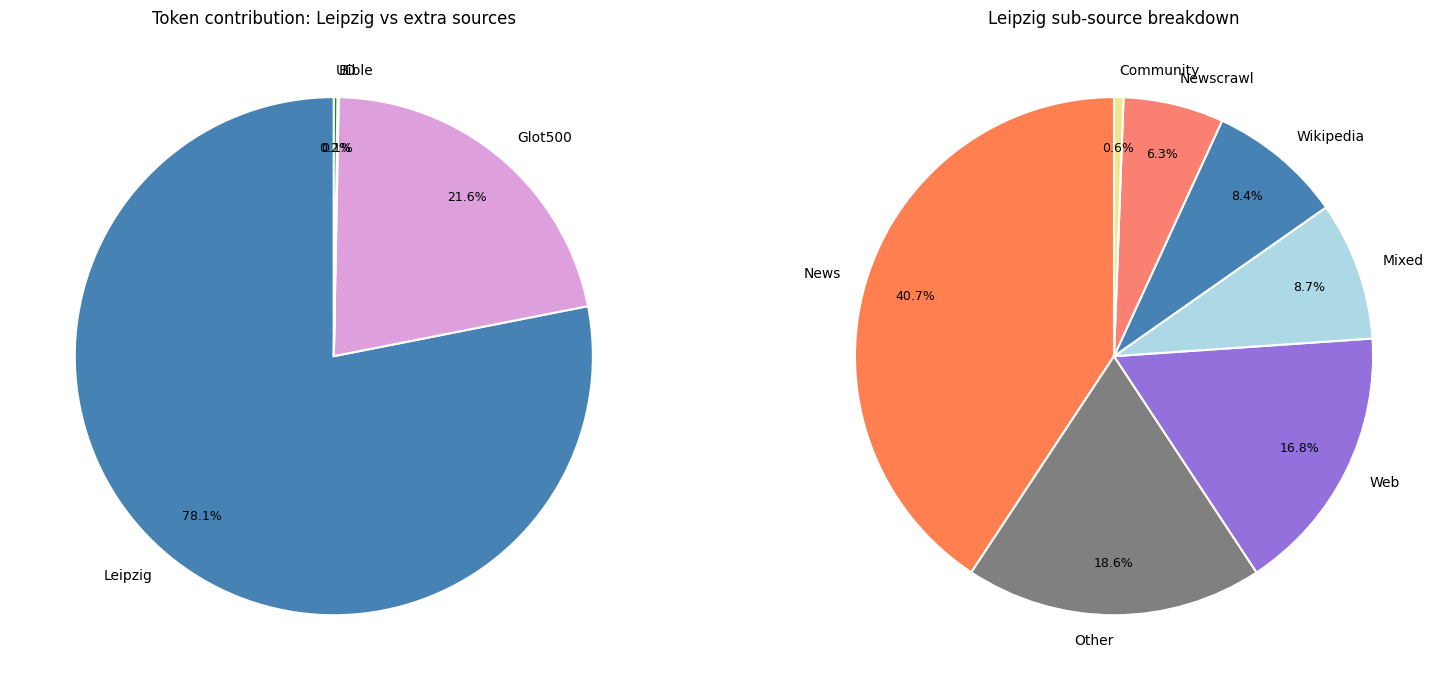

In [42]:

# ── Pie charts: source contributions ────────────────────────

EXTRA = {"Bible", "UD", "Glot500", "TIL"}
LEIPZIG_SOURCES = [s for s in all_sources if s not in EXTRA]

# Aggregate totals
extra_totals = {src: df_sources[src].sum() for src in all_sources if src in EXTRA}
leipzig_total = sum(df_sources[src].sum() for src in LEIPZIG_SOURCES)

# ── Left pie: Leipzig vs Bible vs Glot500 vs UD ──
pie1_labels = ["Leipzig"] + [s for s in ["Glot500", "Bible", "UD", "TIL"] if extra_totals.get(s, 0) > 0]
pie1_sizes = [leipzig_total] + [extra_totals[s] for s in ["Glot500", "Bible", "UD", "TIL"] if extra_totals.get(s, 0) > 0]
pie1_colors = ["steelblue", "plum", "goldenrod", "forestgreen", "darkorange"][:len(pie1_labels)]

# ── Right pie: Leipzig sub-source breakdown ──
pie2_data = {src: df_sources[src].sum() for src in LEIPZIG_SOURCES if df_sources[src].sum() > 0}
pie2_data = dict(sorted(pie2_data.items(), key=lambda x: x[1], reverse=True))
colors_map = {
    "News": "coral", "Newscrawl": "salmon", "Web": "mediumpurple",
    "Wikipedia": "steelblue", "Mixed": "lightblue", "Community": "khaki", "Other": "gray",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left pie
wedges, texts, autotexts = ax1.pie(
    pie1_sizes, labels=pie1_labels, colors=pie1_colors, autopct="%1.1f%%",
    startangle=90, pctdistance=0.8,
    wedgeprops=dict(edgecolor="white", linewidth=1.5))
for t in autotexts:
    t.set_fontsize(9)
for t in texts:
    t.set_fontsize(10)
ax1.set_title("Token contribution: Leipzig vs extra sources")

# Right pie
pie2_labels = list(pie2_data.keys())
pie2_sizes = list(pie2_data.values())
pie2_colors = [colors_map.get(l, "gray") for l in pie2_labels]

wedges2, texts2, autotexts2 = ax2.pie(
    pie2_sizes, labels=pie2_labels, colors=pie2_colors, autopct="%1.1f%%",
    startangle=90, pctdistance=0.8,
    wedgeprops=dict(edgecolor="white", linewidth=1.5))
for t in autotexts2:
    t.set_fontsize(9)
for t in texts2:
    t.set_fontsize(10)
ax2.set_title("Leipzig sub-source breakdown")

plt.tight_layout()
plt.show()


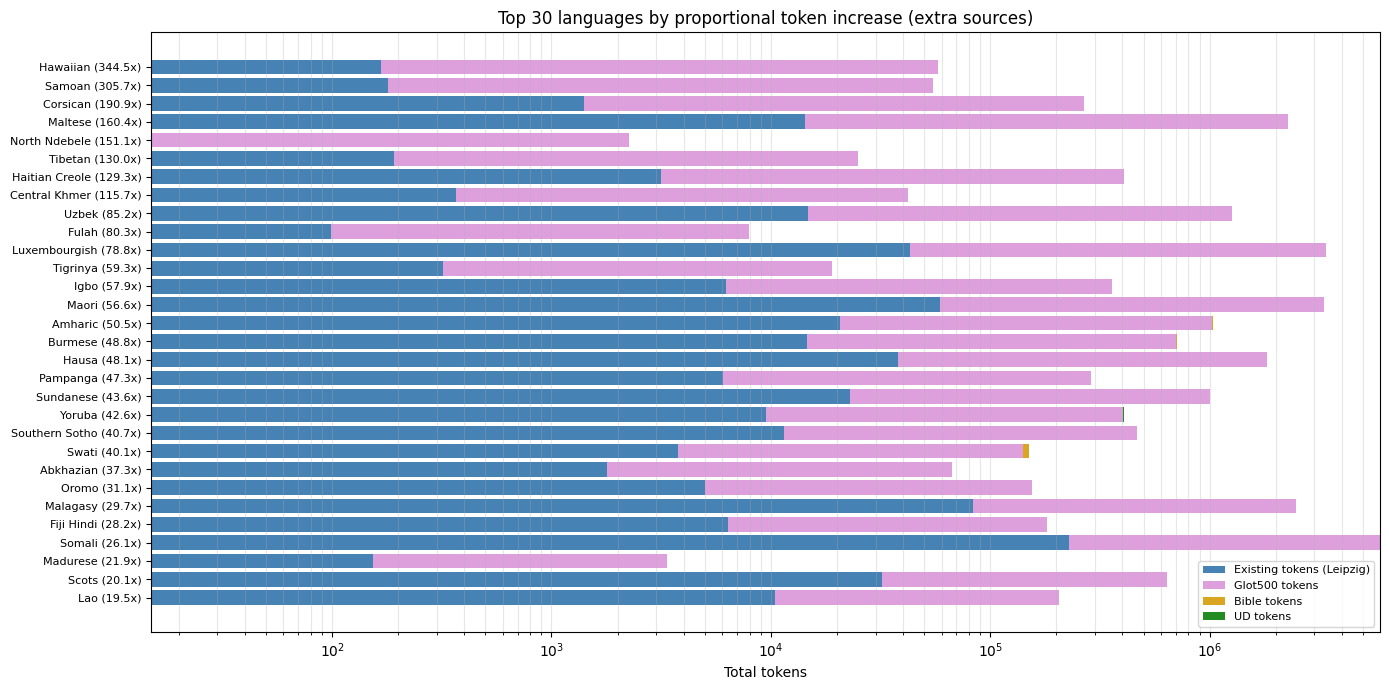

Languages with Bible   data:  65  (     56,955,317 tokens)
Languages with UD      data:  90  (    162,475,459 tokens)
Languages with Glot500 data: 232  ( 15,801,168,254 tokens)

Top 10 by proportional raise:
 Lang  Name                          Existing    Glot500      Bible         UD        After   Ratio
  haw  Hawaiian                           167     57,368          0          0       57,535 344.52x
  smo  Samoan                             180     54,849          0          0       55,029 305.72x
  cos  Corsican                         1,403    266,429          0          0      267,832 190.90x
  mlt  Maltese                         14,250  2,270,846          0        394    2,285,490 160.39x
  nde  North Ndebele                       15      2,252          0          0        2,267 151.13x
  bod  Tibetan                            191     24,638          0          0       24,829 129.99x
  hat  Haitian Creole                   3,149    403,877          0        242      407,268 

In [43]:

# ── Bar chart: top 30 languages by proportional token increase ──

df_extra = df_sources[df_sources["extra"] > 0].copy()
df_extra = df_extra[df_extra["existing"] > 0].sort_values("ratio", ascending=False)
TOP_N = 30
df_top = df_extra.head(TOP_N).copy()

fig, ax = plt.subplots(figsize=(14, 7))

y_pos = np.arange(len(df_top))
ax.barh(y_pos, df_top["existing"], color="steelblue", label="Existing tokens (Leipzig)")

left = df_top["existing"].values.copy()
for src, color in [("Glot500", "plum"), ("Bible", "goldenrod"), ("UD", "forestgreen"), ("TIL", "darkorange")]:
    if src in df_top.columns:
        vals = df_top[src].values
        ax.barh(y_pos, vals, left=left, color=color, label=f"{src} tokens")
        left = left + vals

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['name']} ({row.ratio:.1f}x)" for _, row in df_top.iterrows()], fontsize=8)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Total tokens")
ax.set_title(f"Top {TOP_N} languages by proportional token increase (extra sources)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, axis="x", alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# Print summary
for src in extra_cols:
    n = (df_sources[src] > 0).sum()
    total = df_sources[src].sum()
    print(f"Languages with {src:7s} data: {n:3d}  ({total:>15,} tokens)")
print(f"\nTop 10 by proportional raise:")
print(f"{'Lang':>5}  {'Name':<25} {'Existing':>12} {'Glot500':>10} {'Bible':>10} {'UD':>10} {'After':>12} {'Ratio':>7}")
for _, r in df_top.head(10).iterrows():
    print(f"{r.lang:>5}  {r['name']:<25} {r.existing:>12,.0f} {r.get('Glot500',0):>10,.0f} {r.get('Bible',0):>10,.0f} {r.get('UD',0):>10,.0f} {r.total:>12,.0f} {r.ratio:>6.2f}x")
